In [92]:
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X = np.array([
    10, 12, 15, 18, 20, 22, 25, 28, 30, 32,
    35, 37, 40, 42, 45, 48, 50, 52, 55, 58,
    60, 62, 65, 68, 20, 72, 75, 78, 80, 85,
    90, 95, 100
])

y = np.array([
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1
])

In [93]:
X = (X - np.mean(X)) / np.std(X)

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [95]:
X_train = np.array([X_train, np.ones(len(X_train))]).T
X_test = np.array([X_test, np.ones(len(X_test))]).T

parameters = np.zeros(X_train.shape[1])

In [96]:
n = len(X_train)
epochs = 200
learning_rate = 0.1
losses = []
for i in range(epochs):
    z = np.dot(X_train , parameters)
    y_pred = 1 / (1 + np.exp(-z))

    gradient = (1 / n) * np.dot(X_train.T, (y_pred - y_train))
    loss = -np.sum(y_train * np.log(y_pred ) + (1 - y_train) * np.log(1 - y_pred )) / n

    losses.append(loss)
    parameters -= learning_rate * gradient
    
print(parameters)
print(losses)
print(loss)

[ 2.32563494 -0.058001  ]
[np.float64(0.693147180559945), np.float64(0.6776099039697135), np.float64(0.6628511368167883), np.float64(0.6488302455315464), np.float64(0.6355079038283845), np.float64(0.622846225686676), np.float64(0.6108088609811377), np.float64(0.599361058237707), np.float64(0.5884696990138297), np.float64(0.5781033082558031), np.float64(0.5682320447194801), np.float64(0.5588276751965922), np.float64(0.5498635359019094), np.float64(0.5413144839736697), np.float64(0.5331568416414709), np.float64(0.5253683352363591), np.float64(0.5179280308664795), np.float64(0.5108162682636326), np.float64(0.5040145940237291), np.float64(0.4975056952175492), np.float64(0.4912733341359659), np.float64(0.4853022847535463), np.float64(0.47957827134323994), np.float64(0.4740879095495642), np.float64(0.46881865012508295), np.float64(0.4637587254520012), np.float64(0.4588970989044714), np.float64(0.45422341705515196), np.float64(0.44972796468934473), np.float64(0.4454016225596271), np.float64(0

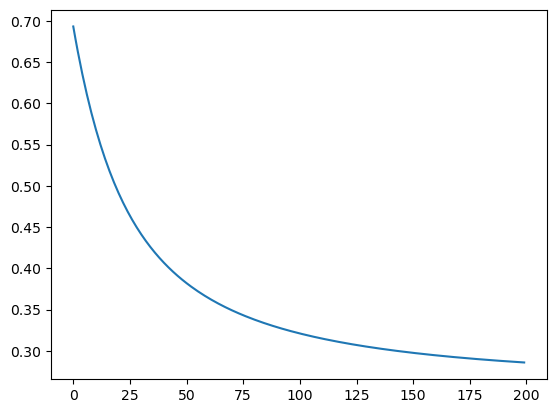

In [97]:
plt.plot(losses)

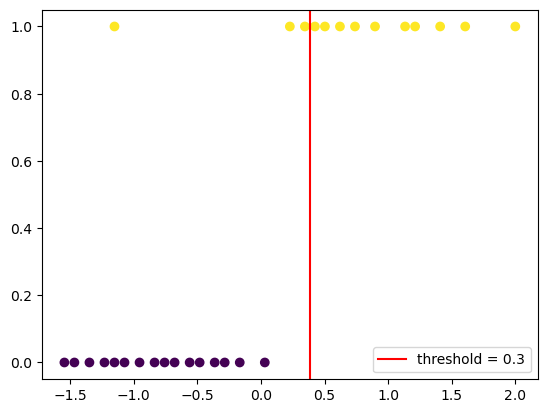

In [ ]:
w = parameters[0]
b = parameters[1]

threshold = 0.7

# σ(z)=0.3
# z=log(0.3/1-0.3​)
z_thresh = np.log(threshold / (1 - threshold))

x_boundary = (z_thresh - b) / w
print(x_boundary)
plt.scatter(X_train[:,0] , y_train , c = y_train)

plt.axvline(x_boundary, color='red', label="threshold = 0.3")

plt.legend()
plt.show()

In [99]:
z = np.dot(X_test , parameters)
y_pred_test = 1 / (1 + np.exp(-z))
loss = -np.sum(y_test * np.log(y_pred_test) +(1 - y_test) * np.log(1 - y_pred_test)) / n
print(loss)

0.052416089421933605


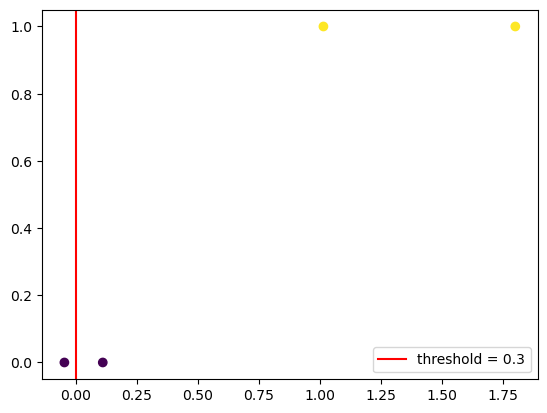

In [100]:
plt.scatter(X_test[:,0] , y_test , c = y_test)

plt.axvline(z_thresh , color='red', label="threshold = 0.3")

plt.legend()
plt.show()